> Federated Learning workflow with Autonomous client and model aggregation methos selection

### 1. Import Libraries

In [31]:
from collections import deque, defaultdict
import copy
from dataclasses import dataclass, asdict, field
import graphviz 
import json
import logging
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as mpaches
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import pandas as pd
import random
from scipy import stats, signal
from scipy.optimize import minimize
import seaborn as sns
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import syft as sy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchmetrics import Accuracy, Precision, Recall
import torchvision
from torchvision import datasets, transforms
from tqdm import tqdm
from typing import Dict, List, Optional, Tuple
import time

import warnings
warnings.filterwarnings('ignore')

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

training_harware = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using training_harware: {training_harware}")

Using training_harware: cpu


### 2. Model building

In [6]:
class SimpleNet(nn.Module): # A simple CNN for image classification
   def __init__(self, in_channels: int = 1, num_classes: int = 10):

       """
       Building blocks of convolutional neural network.

       Parameters:
           * in_channels: Number of channels in the input image (for grayscale images, 1)
           * num_classes: Number of classes to predict. In our problem, 10 (i.e digits from  0 to 9).
       """
       super(SimpleNet, self).__init__()

       # 1st convolutional layer
       self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
       # Max pooling layer
       self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
       # 2nd convolutional layer
       self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
       # Fully connected layer
       self.fc1 = nn.Linear(16 * 7 * 7, num_classes)

   def forward(self, x):
       """
       Define the forward pass of the neural network.

       Parameters:
           x: Input tensor.

       Returns:
           torch.Tensor
               The output tensor after passing through the network.
       """
       x = F.relu(self.conv1(x))  # Apply first convolution and ReLU activation
       x = self.pool(x)           # Apply max pooling
       x = F.relu(self.conv2(x))  # Apply second convolution and ReLU activation
       x = self.pool(x)           # Apply max pooling
       x = x.reshape(x.shape[0], -1)  # Flatten the tensor
       x = self.fc1(x)            # Apply fully connected layer
       return x

In [7]:
def local_train(model:SimpleNet, loader, epochs: int = 1, lr: float = 0.01, resources_info: Dict = {}) -> Tuple[float, Dict]:
    """Local training with gradient quality measurement"""
    model.train()
    # Define the loss function
    criterion = nn.CrossEntropyLoss()
    # Define the optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    gradient_norms = []

    for _ in range(epochs):
        for batch_index, (data, targets) in enumerate(tqdm(loader, desc="Training", leave=False)):
            data = data.to(training_harware)
            targets = targets.to(training_harware)
            output = model(data)
            loss = criterion(output, targets)
            optimizer.zero_grad()
            loss.backward()

            # Calculate gradient norm
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** (1. / 2)
            gradient_norms.append(total_norm)

            optimizer.step()

    training_time = random.uniform(0.5, 2.0) * epochs  # Simulated training time
    gradient_quality = np.mean(gradient_norms) if gradient_norms else 0.0
    
    return training_time, model.state_dict(), gradient_quality

def evaluate(model, loader):
    # Set up of multiclass accuracy metric
    acc = Accuracy(task="multiclass",num_classes=10)

    # Iterate over the dataset batches
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            # Get predicted probabilities for test data batch
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            acc(preds, labels)
            # precision = Precision(preds, labels)
            # recall = Recall(preds, labels)

    #Compute total test accuracy
    test_accuracy = acc.compute()
    print(f"Test accuracy: {test_accuracy}")

    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in loader:
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
    accuracy = correct / len(loader.dataset)
    print(f"✅ Global model accuracy: {accuracy:.4f}")
    return accuracy


### 3. Dataset preparation

In [8]:
batch_size = 60

train_dataset = datasets.MNIST(root="data/", download=True, train=True, transform=transforms.ToTensor())

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = datasets.MNIST(root="data/", download=True, train=False, transform=transforms.ToTensor())

test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)


#### 3.1. Data Distribution for Federated Learning

In [9]:
def create_non_iid_data_split(dataset, num_clients, alpha=0.5):
    """
    Create non-IID data splits using Dirichlet distribution
    
    Args:
        dataset: PyTorch dataset (MNIST)
        num_clients: Number of clients to split data among
        alpha: Dirichlet concentration parameter (lower = more heterogeneous)
    
    Returns:
        client_datasets: Dict mapping client_id to dataset indices
        client_stats: Dict with data distribution statistics
    """
    # Get labels
    labels = np.array([dataset[i][1] for i in range(len(dataset))])
    num_classes = len(np.unique(labels))
    
    # Group indices by class
    class_indices = {i: np.where(labels == i)[0] for i in range(num_classes)}
    
    # Generate Dirichlet distribution for each client
    client_datasets = {}
    client_stats = {}
    
    for client_id in range(num_clients):
        # Sample proportions from Dirichlet distribution
        proportions = np.random.dirichlet([alpha] * num_classes)
        
        # Calculate number of samples per class for this client
        client_indices = []
        class_counts = {}
        
        total_samples_per_client = len(dataset) // num_clients
        
        for class_idx in range(num_classes):
            n_samples = int(proportions[class_idx] * total_samples_per_client)
            if n_samples > 0 and len(class_indices[class_idx]) > 0:
                # Randomly sample from available indices for this class
                available_indices = class_indices[class_idx]
                selected_indices = np.random.choice(
                    available_indices, 
                    min(n_samples, len(available_indices)), 
                    replace=False
                )
                client_indices.extend(selected_indices)
                class_counts[class_idx] = len(selected_indices)
                
                # Remove selected indices from available pool
                class_indices[class_idx] = np.setdiff1d(available_indices, selected_indices)
        
        client_datasets[f"client_{client_id}"] = client_indices
        client_stats[f"client_{client_id}"] = {
            'total_samples': len(client_indices),
            'class_distribution': class_counts,
            'heterogeneity_score': np.std(list(class_counts.values()))
        }
    
    return client_datasets, client_stats

def calculate_data_heterogeneity(client_stats):
    """Calculate overall data heterogeneity metrics"""
    all_distributions = []
    for stats_i in client_stats.values():
        dist = list(stats_i['class_distribution'].values())
        # Normalize to get proportions
        total = sum(dist)
        if total > 0:
            all_distributions.append([x/total for x in dist])
    
    if not all_distributions:
        return 0.0
    
    # Calculate Jensen-Shannon divergence as heterogeneity measure
    mean_dist = np.mean(all_distributions, axis=0)
    js_div = 0
    for dist in all_distributions:
        js_div += stats.entropy(dist, mean_dist)
    
    return js_div / len(all_distributions)


### 4. IoT devices/clients building

#### 4.1. Resource Information

In [10]:
# IoT Device and Gateway Communication Simulation
@dataclass
class BatteryState:
    design_capacity: float  # mAh
    current_capacity: float  # mAh (degrades over time)
    current_level: float  # percentage (0-100)
    voltage: float  # volts
    discharge_rate: float  # mA/h
    temperature: float  # Celsius
    cycle_count: int = 0  # number of charge/discharge cycles
    degradation_rate: float = 0.001  # capacity loss per cycle
    temperature_coefficient: float = -0.5  # %/°C performance impact
    age_days: int = 0
    last_charge_time: float = 0.0
    estimated_remaining: float = 0.0
    health_percentage: float = 100.0


@dataclass
class BandwidthState:
    max_uplink: float  # Mbps
    max_downlink: float  # Mbps
    current_uplink: float  # Mbps
    current_downlink: float  # Mbps
    packet_loss: float  # percentage
    base_latency: float  # milliseconds
    current_latency: float  # milliseconds
    jitter: float  # milliseconds
    signal_strength: float = -70.0  # dBm
    interference_level: float = 0.0  # 0-1 scale
    network_congestion: float = 0.0  # 0-1 scale
    connection_stability: float = 1.0  # 0-1 scale
    last_bandwidth_test: float = 0.0
    throughput_history: list = field(default_factory=list)


@dataclass
class MemoryState:
    total_ram: int  # KB
    used_ram: int  # KB
    free_ram: int  # KB
    buffer_usage: int  # KB
    cache_usage: int  # KB
    fragmentation_level: float = 0.0  # 0-1 scale
    memory_pressure: float = 0.0  # 0-1 scale
    gc_frequency: float = 1.0  # garbage collection frequency
    allocation_failures: int = 0
    peak_usage: int = 0
    memory_leaks: float = 0.0  # gradual memory loss
    compression_ratio: float = 1.0


@dataclass
class DeviceHealthMetrics:
    cpu_temperature: float = 25.0
    cpu_utilization: float = 0.0
    disk_usage: float = 0.0
    network_errors: int = 0
    system_uptime: float = 0.0
    failure_probability: float = 0.0
    maintenance_due: bool = False
    last_health_check: float = 0.0
    performance_score: float = 1.0


@dataclass
class Packet:
    source_id: str
    destination: str
    size: int  # bytes
    timestamp: float
    packet_type: str
    # priority: int          # 1-5 (5 = highest priority)
    retry_count: int  # number of retransmission attempts
    data: Optional[Dict] = None

#### 4.2. Resource Monitoring and Prediction

In [11]:
class BatteryDegradationModel:
    """Realistic battery degradation simulation"""
    
    @staticmethod
    def calculate_capacity_loss(battery: BatteryState, time_delta: float) -> float:
        """Calculate battery capacity loss over time"""
        # Calendar aging (time-based degradation)
        calendar_loss = 0.0001 * time_delta / 3600  # 0.01% per hour base rate
        
        # Temperature effect (Arrhenius equation approximation)
        temp_factor = math.exp((battery.temperature - 25) / 10)
        calendar_loss *= temp_factor
        
        # Cycle aging (usage-based degradation)
        cycle_loss = battery.cycle_count * battery.degradation_rate
        
        return min(calendar_loss + cycle_loss, 0.8)  # Max 80% degradation

    @staticmethod
    def update_battery_health(battery: BatteryState, time_delta: float, usage_intensity: float):
        """Update battery state over time"""
        # Calculate degradation
        capacity_loss = BatteryDegradationModel.calculate_capacity_loss(battery, time_delta)
        battery.current_capacity = battery.design_capacity * (1 - capacity_loss)
        battery.health_percentage = (battery.current_capacity / battery.design_capacity) * 100
        
        # Update discharge rate based on temperature
        temp_effect = 1 + (battery.temperature - 25) * battery.temperature_coefficient / 100
        battery.discharge_rate = battery.discharge_rate * temp_effect
        
        # Simulate usage cycles
        if usage_intensity > 0.5:  # High usage triggers cycle count
            battery.cycle_count += time_delta / 3600  # Approximate cycles per hour
        
        # Update estimated remaining time
        if battery.discharge_rate > 0:
            battery.estimated_remaining = (battery.current_level / 100) * battery.current_capacity / battery.discharge_rate

class NetworkConditionModel:
    """Dynamic network condition simulation"""
    
    @staticmethod
    def simulate_network_fluctuation(bandwidth: BandwidthState, time_delta: float, location: Tuple[float, float]):
        """Simulate realistic network condition changes"""
        # Time-based interference patterns (e.g., daily patterns)
        time_of_day = (time.time() % 86400) / 86400  # 0-1 representing day progress
        daily_congestion = 0.3 + 0.4 * math.sin(2 * math.pi * (time_of_day - 0.25))  # Peak at midday
        
        # Location-based interference (simplified)
        location_factor = (hash(str(location)) % 100) / 100  # Deterministic but location-dependent
        
        # Random fluctuations
        random_factor = np.random.normal(1.0, 0.1)
        
        # Update network congestion
        bandwidth.network_congestion = np.clip(daily_congestion * location_factor * random_factor, 0, 1)
        
        # Update signal strength with interference
        base_signal = -70.0  # dBm
        interference_impact = bandwidth.interference_level * 20  # dB loss
        bandwidth.signal_strength = base_signal - interference_impact + np.random.normal(0, 5)
        
        # Update effective bandwidth
        congestion_factor = 1 - bandwidth.network_congestion * 0.7
        signal_factor = min(1.0, (bandwidth.signal_strength + 100) / 30)  # Signal quality factor
        
        bandwidth.current_uplink = bandwidth.max_uplink * congestion_factor * signal_factor
        bandwidth.current_downlink = bandwidth.max_downlink * congestion_factor * signal_factor
        
        # Update latency based on conditions
        base_latency_increase = bandwidth.network_congestion * 50  # ms
        signal_latency_increase = max(0, (-70 - bandwidth.signal_strength)) * 2  # ms per dB below -70
        bandwidth.current_latency = bandwidth.base_latency + base_latency_increase + signal_latency_increase
        
        # Update packet loss
        loss_from_congestion = bandwidth.network_congestion * 5  # Up to 5% from congestion
        loss_from_signal = max(0, (-80 - bandwidth.signal_strength)) * 0.5  # Loss from poor signal
        bandwidth.packet_loss = np.clip(loss_from_congestion + loss_from_signal, 0, 20)
        
        # Update connection stability
        stability_factors = [
            1 - bandwidth.network_congestion * 0.3,
            min(1.0, (bandwidth.signal_strength + 90) / 20),
            1 - bandwidth.interference_level * 0.4
        ]
        bandwidth.connection_stability = np.mean(stability_factors)

class MemoryManagementModel:
    """Advanced memory management simulation"""
    
    @staticmethod
    def simulate_memory_fragmentation(memory: MemoryState, time_delta: float, workload_intensity: float):
        """Simulate memory fragmentation over time"""
        # Fragmentation increases with usage and time
        fragmentation_increase = workload_intensity * time_delta * 0.001
        memory.fragmentation_level = min(1.0, memory.fragmentation_level + fragmentation_increase)
        
        # Memory pressure based on usage
        usage_ratio = memory.used_ram / memory.total_ram
        memory.memory_pressure = max(0, (usage_ratio - 0.7) / 0.3)  # Pressure starts at 70% usage
        
        # Garbage collection frequency adapts to pressure
        memory.gc_frequency = 1.0 + memory.memory_pressure * 2.0
        
        # Memory leaks (gradual loss of available memory)
        leak_rate = 0.1 * workload_intensity * time_delta / 3600  # KB per hour
        memory.memory_leaks = min(memory.total_ram * 0.1, memory.memory_leaks + leak_rate)
        
        # Update effective free memory
        effective_total = memory.total_ram - memory.memory_leaks
        fragmentation_overhead = memory.fragmentation_level * effective_total * 0.1
        memory.free_ram = max(0, effective_total - memory.used_ram - fragmentation_overhead)

class EnvironmentalModel:
    """Environmental condition simulation"""
    
    @staticmethod
    def simulate_temperature_variation(base_temp: float, time_delta: float, device_type: str) -> float:
        """Simulate realistic temperature changes"""
        # Daily temperature cycle
        time_of_day = (time.time() % 86400) / 86400
        daily_variation = 10 * math.sin(2 * math.pi * (time_of_day - 0.25))  # Peak at midday
        
        # Device type affects heat generation
        heat_generation = {
            'sensor': 2.0,
            'camera': 8.0,
            'actuator': 5.0,
            'tracker': 3.0,
            'gateway': 15.0
        }.get(device_type, 3.0)
        
        # Random fluctuations
        random_variation = np.random.normal(0, 2)
        
        return base_temp + daily_variation + heat_generation + random_variation


#### 4.3. IoT Device

In [12]:
class IoTDevice:
    def __init__(
        self,
        device_id: str,
        device_type: str = "sensor",
        initial_battery: float = 100.0,
        location: Tuple[float, float] = (0.0, 0.0),
        local_model: SimpleNet = SimpleNet(),
        local_data_indices: List[int] = None,
    ):
        self.device_id = device_id
        self.device_type = device_type
        self.location = location  # (x, y) coordinates
        self.creation_time = time.time()
        self.local_data_indices = local_data_indices or []
        self.local_train_loader = None
        self.data_quality_score = 0.0
        self.participation_history = []
        self.rounds_since_participation = 0
        self.total_participation_count = 0
        self.gradient_quality_history = []
        self.reliability_score = 1.0
        self.energy_consumption_history = []

        # ML model for federated learning
        self.local_model = local_model

        # Real-world IoT device specifications
        device_specs = self._get_device_specifications(device_type)

        self.battery = BatteryState(
            design_capacity=device_specs["battery_capacity"],
            current_level=initial_battery,
            current_capacity=device_specs["battery_capacity"],
            voltage=device_specs["battery_voltage"],
            discharge_rate=device_specs["discharge_rate"],
            temperature=random.uniform(20.0, 35.0),
        )

        self.bandwidth = BandwidthState(
            max_uplink=device_specs["max_uplink"],
            max_downlink=device_specs["max_downlink"],
            current_uplink=device_specs["max_uplink"],
            current_downlink=device_specs["max_downlink"],
            packet_loss=0.0,
            base_latency=random.uniform(10, 50),
            current_latency=random.uniform(10, 50),
            jitter=random.uniform(1, 5),
        )

        self.memory = MemoryState(
            total_ram=device_specs["total_ram"],
            used_ram=0,
            free_ram=device_specs["total_ram"],
            buffer_usage=0,
            cache_usage=0,
        )

        self.is_active = True
        self.packet_queue = deque(maxlen=device_specs["queue_limit"])
        self.last_transmission = time.time()
        self.network_condition = "GOOD"  # Current network state
        self.energy_harvesting = device_specs.get("energy_harvesting", False)
        self.sleep_mode = False
        self.health_metrics = DeviceHealthMetrics()
        self.last_state_update = time.time()
        self.workload_history = deque(maxlen=50)
        self.performance_trend = deque(maxlen=20)

        # Update initial memory state
        self.stats = {
            "packets_sent": 0,
            "packets_failed": 0,
            "total_data_sent": 0,
            "avg_power_consumption": 0.0,
            "connection_uptime": 0.0,
        }

        # self._update_memory_state()
        logger.info(
            f"Device {device_id} ({device_type}) initialized at {location} with {self.battery.design_capacity}mAh battery"
        )

    def simulate_time_passage(self, time_delta: float):
        """Simulate the passage of time and update all device states"""
        current_time = time.time()

        # Calculate workload intensity from recent activity
        workload_intensity = len(self.packet_queue) / (self.packet_queue.maxlen or 1)
        self.workload_history.append(workload_intensity)

        # Update battery state
        BatteryDegradationModel.update_battery_health(
            self.battery, time_delta, workload_intensity
        )

        # Update battery level based on usage
        energy_consumed = (
            self.battery.discharge_rate * time_delta / 3600
        )  # mAh consumed
        if self.battery.current_capacity > 0:
            level_decrease = (energy_consumed / self.battery.current_capacity) * 100
            self.battery.current_level = max(
                0, self.battery.current_level - level_decrease
            )

        # Update network conditions
        NetworkConditionModel.simulate_network_fluctuation(
            self.bandwidth, time_delta, self.location
        )

        # Update memory state
        MemoryManagementModel.simulate_memory_fragmentation(
            self.memory, time_delta, workload_intensity
        )

        # Update environmental conditions
        self.battery.temperature = EnvironmentalModel.simulate_temperature_variation(
            self.battery.temperature, time_delta, self.device_type
        )

        # Update health metrics
        self._update_health_metrics(workload_intensity)

        # Record performance trend
        performance_score = self._calculate_performance_score()
        self.performance_trend.append(performance_score)

        self.last_state_update = current_time

    def _update_health_metrics(self, workload_intensity: float):
        """Update device health metrics"""
        # CPU utilization correlates with workload
        self.health_metrics.cpu_utilization = min(
            1.0, workload_intensity + np.random.normal(0, 0.1)
        )

        # CPU temperature affected by utilization
        temp_increase = self.health_metrics.cpu_utilization * 20
        self.health_metrics.cpu_temperature = self.battery.temperature + temp_increase

        # System uptime
        self.health_metrics.system_uptime = time.time() - self.creation_time

        # Failure probability based on multiple factors
        age_factor = min(
            1.0, self.health_metrics.system_uptime / (365 * 24 * 3600)
        )  # Age in years
        battery_factor = 1 - (self.battery.health_percentage / 100)
        temp_factor = max(
            0, (self.health_metrics.cpu_temperature - 60) / 40
        )  # Risk above 60°C

        self.health_metrics.failure_probability = np.clip(
            age_factor * 0.1 + battery_factor * 0.3 + temp_factor * 0.4, 0, 1
        )

        # Performance score (0-1)
        self.health_metrics.performance_score = 1.0 - (
            battery_factor * 0.3
            + self.memory.fragmentation_level * 0.2
            + (1 - self.bandwidth.connection_stability) * 0.3
            + temp_factor * 0.2
        )

    def _calculate_performance_score(self) -> float:
        """Calculate overall device performance score"""
        battery_score = self.battery.current_level / 100.0
        memory_score = self.memory.free_ram / self.memory.total_ram
        network_score = self.bandwidth.connection_stability
        health_score = self.health_metrics.performance_score

        return np.mean([battery_score, memory_score, network_score, health_score])

    def predict_remaining_lifetime(self) -> float:
        """Predict remaining operational lifetime in hours"""
        if self.battery.current_level <= 0:
            return 0.0

        # Current battery life
        battery_hours = self.battery.estimated_remaining

        # Factor in degradation trend
        if len(self.performance_trend) > 5:
            trend_slope = np.polyfit(
                range(len(self.performance_trend)), list(self.performance_trend), 1
            )[0]
            # Adjust lifetime based on performance trend
            trend_factor = max(0.5, 1 + trend_slope * 10)
            battery_hours *= trend_factor

        # Factor in failure probability
        reliability_factor = 1 - self.health_metrics.failure_probability

        return battery_hours * reliability_factor

    def assign_local_data(self, dataset, indices):
        """Assign local dataset to device"""
        self.local_data_indices = indices
        subset = Subset(dataset, indices)
        self.local_train_loader = DataLoader(subset, batch_size=32, shuffle=True)

        # Calculate data quality metrics
        labels = [dataset[i][1] for i in indices]
        unique_labels, counts = np.unique(labels, return_counts=True)
        self.data_quality_score = (
            len(unique_labels) / 10.0
        )  # Normalize by total classes

        logger.info(
            f"Device {self.device_id} assigned {len(indices)} samples with {len(unique_labels)} classes"
        )

    def update_participation_metrics(
        self, participated: bool, gradient_quality: float = 0.0
    ):
        """Update participation and performance metrics"""
        self.participation_history.append(participated)
        if participated:
            self.rounds_since_participation = 0
            self.total_participation_count += 1
            if gradient_quality > 0:
                self.gradient_quality_history.append(gradient_quality)
        else:
            self.rounds_since_participation += 1

        # Keep only last 50 rounds of history
        if len(self.participation_history) > 50:
            self.participation_history = self.participation_history[-50:]

    def get_selection_features(self) -> np.ndarray:
        """Extract features for decision tree selection"""
        # Temporal and predictive features
        performance_score = self._calculate_performance_score()
        lifetime_prediction = min(
            1.0, self.predict_remaining_lifetime() / 24.0
        )  # Normalize to 24h

        # Stability metrics
        network_stability = self.bandwidth.connection_stability
        battery_health = self.battery.health_percentage / 100.0
        memory_efficiency = 1.0 - self.memory.fragmentation_level

        # Trend analysis
        performance_trend = 0.5  # Neutral if no history
        if len(self.performance_trend) > 3:
            recent_trend = np.mean(list(self.performance_trend)[-3:])
            performance_trend = recent_trend
            
        # Comprehensive feature vector
        features = [
            self.battery.current_level / 100.0,  # Battery level [0,1]
            (self.memory.total_ram - self.memory.used_ram)
            / self.memory.total_ram,  # Free memory ratio
            (100 - self.bandwidth.packet_loss) / 100.0,  # Network reliability
            min(1.0, self.data_quality_score),  # Data quality [0,1]
            min(1.0, self.rounds_since_participation / 10.0),  # Fairness consideration
            self.reliability_score,  # Historical reliability
            len(self.local_data_indices) / 1000.0,  # Data volume (normalized)
            (
                np.mean(self.gradient_quality_history[-5:])
                if self.gradient_quality_history
                else 0.0
            ),  # Recent gradient quality
            performance_score,
            lifetime_prediction,
            network_stability,
            battery_health,
            memory_efficiency,
            performance_trend,
        ]
        return np.array(features)

    def _get_device_specifications(self, device_type: str) -> Dict:
        """Get realistic specifications for different IoT device types"""
        specs = {
            "sensor": {
                "total_ram": random.randint(8, 64),
                "battery_voltage": 3.3,
                "battery_capacity": random.uniform(500, 2000),
                "discharge_rate": random.uniform(0.5, 5.0),  # mAh/h
                "max_uplink": 0.025,  # LoRaWAN typical
                "max_downlink": 0.025,
                "queue_limit": 10,
                "energy_harvesting": random.choice(
                    [True, False]
                ),  # Some sensors have solar panels
            },
            "actuator": {
                "total_ram": random.randint(16, 128),
                "battery_voltage": 3.7,
                "battery_capacity": random.uniform(1000, 3000),
                "discharge_rate": random.uniform(5.0, 20.0),
                "max_uplink": 0.1,
                "max_downlink": 0.2,
                "queue_limit": 20,
                "energy_harvesting": False,
            },
            "camera": {
                "total_ram": random.randint(512, 2048),
                "battery_voltage": 3.7,
                "battery_capacity": random.uniform(3000, 8000),
                "discharge_rate": random.uniform(50.0, 200.0),
                "max_uplink": 2.0,
                "max_downlink": 0.5,
                "queue_limit": 50,
                "energy_harvesting": False,
            },
            "gateway": {
                "total_ram": random.randint(1024, 8192),
                "battery_voltage": 5.0,
                "battery_capacity": random.uniform(10000, 20000),
                "discharge_rate": random.uniform(100.0, 500.0),
                "max_uplink": 10.0,
                "max_downlink": 10.0,
                "queue_limit": 100,
                "energy_harvesting": False,
            },
            "tracker": {
                "total_ram": random.randint(32, 256),
                "battery_voltage": 3.6,
                "battery_capacity": random.uniform(800, 2500),
                "discharge_rate": random.uniform(2.0, 15.0),
                "max_uplink": 0.05,
                "max_downlink": 0.05,
                "queue_limit": 15,
                "energy_harvesting": random.choice([True, False]),
            },
        }
        return specs.get(device_type, specs["sensor"])

    def can_participate(self) -> bool:
        """Check if device can participate in training"""
        # Basic resource checks
        battery_ok = self.battery.current_level > 15  # Increased threshold
        memory_ok = (self.memory.free_ram / self.memory.total_ram) > 0.2
        network_ok = self.bandwidth.connection_stability > 0.6
        health_ok = self.health_metrics.failure_probability < 0.7

        # Predictive checks
        lifetime_ok = (
            self.predict_remaining_lifetime() > 1.0
        )  # At least 2 hours remaining
        performance_ok = self._calculate_performance_score() > 0.3

        return all(
            [battery_ok, memory_ok, network_ok, health_ok, lifetime_ok, performance_ok]
        )

    def train_model_and_generate_packet(
        self,
        destination: str,
        epochs: int,
        round_num: int,
        global_update: dict[str, any],
        train_loader: DataLoader = train_loader,
    ) -> Packet:
        """Enhanced packet generation with priority and adaptive sizing"""

        if not self.local_train_loader:
            logger.warning(f"Device {self.device_id} has no local data assigned")
            return None

        packet_types = ["global_model", "local_update"]

        # Deive resource info
        resources_info = {
            "battery": asdict(self.battery),
            "bandwidth": asdict(self.bandwidth),
            "memory": asdict(self.memory),
            "location": self.location,
            "stats": self.stats.copy(),
        }

        # Load global updated model if available
        self.local_model.load_state_dict(global_update)

        # Local model training
        training_time, local_update, gradient_quality = local_train(
            model=self.local_model,
            loader=train_loader,
            epochs=epochs,
            resources_info=resources_info,
        )
        packet_size = len(local_update) / (1024 * 1024)  # MB

        packet = Packet(
            source_id=self.device_id,
            destination=destination,
            size=packet_size,
            timestamp=time.time(),
            packet_type=packet_types[1],
            retry_count=0,
            data={
                "local_update": local_update,
                "training_time": training_time,
                "gradient_quality": gradient_quality,
                "data_samples": len(self.local_data_indices),
            },
        )

        if len(self.packet_queue) < self.packet_queue.maxlen:
            self.packet_queue.append(packet)
        else:
            logger.warning(f"Packet queue full for device {self.device_id}")

        return packet

    def transmit_packet(self) -> Optional[Tuple[bool, Packet]]:
        """Simulate packet transmission with resource updates"""
        if not self.packet_queue or self.battery.current_level < 5:
            return None

        # Enter sleep mode if battery is very low
        if self.battery.current_level < 10:
            self.sleep_mode = True
        else:
            self.sleep_mode = False

        packet = self.packet_queue.popleft()

        # Calculate transmission success probability
        success_probability = 0.95  # Base success rate
        if self.network_condition == "BAD":
            success_probability = 0.7
        if self.bandwidth.packet_loss > 10:
            success_probability *= 0.8

        # Simulate transmission attempt
        if random.random() > success_probability:
            packet.retry_count += 1
            if packet.retry_count < 3:  # Allow up to 3 retries
                self.packet_queue.appendleft(packet)  # Put back at front of queue
                self.stats["packets_failed"] += 1
                return None

        self.last_transmission = time.time()
        self.stats["packets_sent"] += 1
        self.stats["total_data_sent"] += packet.size

        return True, packet

    def get_status(self) -> Dict:
        """Get current device status"""
        uptime = time.time() - self.creation_time
        self.stats["connection_uptime"] = uptime

        return {
            "device_id": self.device_id,
            "device_type": self.device_type,
            "location": self.location,
            "is_active": self.is_active and self.battery.current_level > 0,
            "sleep_mode": self.sleep_mode,
            "battery": asdict(self.battery),
            "bandwidth": asdict(self.bandwidth),
            "memory": asdict(self.memory),
            "queue_size": len(self.packet_queue),
            "last_transmission": self.last_transmission,
            "network_condition": self.network_condition,
            "energy_harvesting": self.energy_harvesting,
            "stats": self.stats.copy(),
            "uptime_hours": uptime / 3600,
        }

### 5. Autonomic Computing building

#### 5.1. Decision Tree Dataset Generation

In [ ]:
def generate_decision_tree_training_data(num_samples=10000, save_to_csv=True):
    """Generate synthetic training data for decision tree model"""

    # Feature names matching the mathematical formulation
    feature_names = [
        "battery_level",
        "memory_ratio",
        "network_reliability",
        "data_quality",
        "rounds_since_participation",
        "reliability_score",
        "data_volume",
        "gradient_quality",
        "performance_score",
        "lifetime_prediction",
        "network_stability",
        "battery_health",
        "memory_efficiency",
        "performance_trend",
        "failure_probability",
        "temperature_impact",
        "workload_intensity",
    ]

    # Generate synthetic feature data
    data = []
    labels = []

    for sample_idx in range(num_samples):
        # Generate time-dependent base conditions
        round_progress = (sample_idx % 100) / 100.0  # Simulate rounds 0-99
        device_age = np.random.exponential(50)  # Device age in days
        
        # Phase 1 features with temporal dependencies
        battery_base = np.random.beta(2, 1)
        age_degradation = min(0.3, device_age / 365.0)  # Max 30% degradation after 1 year
        battery_level = max(0, battery_base - age_degradation)
        
        memory_base = np.random.beta(1.5, 1) if battery_level > 0.3 else np.random.beta(1, 2)
        fragmentation = min(0.8, device_age * 0.001)  # Gradual fragmentation
        memory_efficiency = max(0.1, 1 - fragmentation)
        memory_ratio = memory_base * memory_efficiency
        
        # Network conditions with daily patterns
        time_factor = np.sin(2 * np.pi * round_progress)  # Daily network patterns
        base_reliability = np.random.normal(0.85, 0.1)
        network_reliability = np.clip(base_reliability + time_factor * 0.1, 0, 1)
        network_stability = network_reliability * np.random.uniform(0.8, 1.2)
        network_stability = np.clip(network_stability, 0, 1)
        
        data_quality = np.random.beta(2, 2)
        rounds_since_participation = np.random.exponential(3) / 10.0
        rounds_since_participation = min(1.0, rounds_since_participation)
        
        # Reliability with aging effects
        base_reliability_score = np.random.beta(3, 1)
        aging_factor = max(0.5, 1 - age_degradation)
        reliability_score = base_reliability_score * aging_factor
        
        data_volume = np.random.gamma(2, 0.3)
        data_volume = min(1.0, data_volume)
        
        gradient_quality = data_quality * reliability_score * np.random.normal(1, 0.1)
        gradient_quality = np.clip(gradient_quality, 0, 1)
        
        # Phase 2 enhanced features
        performance_components = [battery_level, memory_ratio, network_reliability, reliability_score]
        performance_score = np.mean(performance_components) * np.random.normal(1, 0.05)
        performance_score = np.clip(performance_score, 0, 1)
        
        # Lifetime prediction based on battery and degradation
        base_lifetime = battery_level * 24  # Hours based on battery level
        degradation_impact = age_degradation * 12  # Hours lost due to aging
        lifetime_prediction = max(0, base_lifetime - degradation_impact) / 24.0  # Normalize to 0-1
        
        battery_health = max(0.2, 1 - age_degradation)  # Health percentage
        
        # Failure probability increases with age and poor conditions
        temp_impact = np.random.uniform(0, 0.3)  # Temperature effect
        failure_probability = min(0.9, age_degradation * 0.5 + temp_impact + 
                                (1 - performance_score) * 0.3)
        
        # Performance trend (simplified as random walk)
        performance_trend = np.clip(np.random.normal(0.5, 0.2), 0, 1)
        
        workload_intensity = np.random.beta(2, 5)  # Most devices have low-moderate load
        
        temperature_impact = temp_impact  # Direct use of temperature effect
        
        features = [
            battery_level, memory_ratio, network_reliability, data_quality,
            rounds_since_participation, reliability_score, data_volume, gradient_quality,
            performance_score, lifetime_prediction, network_stability, 
            battery_health, memory_efficiency, performance_trend,
            failure_probability, temperature_impact, workload_intensity
        ]
        
        # Enhanced multi-criteria selection decision
        # Weights adjusted for Phase 2 features
        selection_score = (
            0.20 * battery_level +
            0.10 * memory_ratio +
            0.12 * network_reliability +
            0.15 * data_quality +
            0.08 * (1 - rounds_since_participation) +  # Fairness
            0.10 * reliability_score +
            0.05 * data_volume +
            0.08 * gradient_quality +
            0.12 * performance_score +
            0.05 * lifetime_prediction +
            -0.15 * failure_probability  # Negative weight for failure risk
        )
        
        # Add temporal considerations
        if round_progress < 0.3:  # Early rounds - prioritize fast convergence
            selection_score += 0.1 * data_quality + 0.05 * gradient_quality
        else:  # Later rounds - prioritize network lifetime
            selection_score += 0.1 * battery_level + 0.05 * lifetime_prediction
        
        # Add noise and apply threshold
        selection_score += np.random.normal(0, 0.03)
        should_select = 1 if selection_score > 0.55 else 0
        
        data.append(features)
        labels.append(should_select)
    
    # Create DataFrame
    dt_model_df = pd.DataFrame(data, columns=feature_names)
    dt_model_df["should_select"] = labels

    # Add some temporal patterns
    dt_model_df['round_number'] = np.tile(range(100), num_samples // 100 + 1)[:num_samples]
    dt_model_df['device_type'] = np.random.choice(['sensor', 'camera', 'tracker', 'actuator'], num_samples)
    dt_model_df['device_age_days'] = [np.random.exponential(50) for _ in range(num_samples)]
    

    if save_to_csv:
        dt_model_df.to_csv("device_selection_training_data.csv", index=False)
        print(f"Generated training dataset with {num_samples} samples")
        print(f"Feature distribution summary:")
        # print(dt_model_df.describe())
        print(f"\nSelection rate: {dt_model_df['should_select'].mean():.3f}")
        print(f"Feature correlation with selection:")
        correlations = dt_model_df[feature_names].corrwith(dt_model_df['should_select']).sort_values(ascending=False)
        for feature, corr in correlations.head(5).items():
            print(f"  {feature}: {corr:.3f}")
 
    # Dataset visualization
    display(dt_model_df)

    return dt_model_df


# Generate the training dataset
generate_decision_tree_training_data(num_samples=10000, save_to_csv=True)


#### 5.2. Decision Tree Model

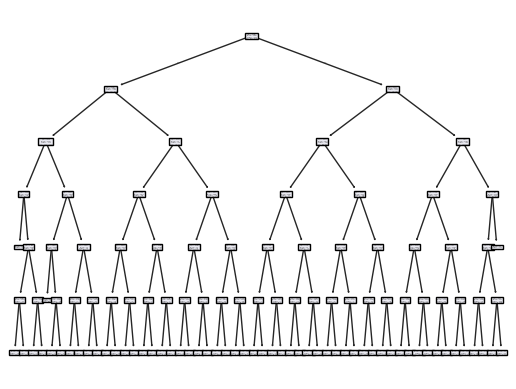

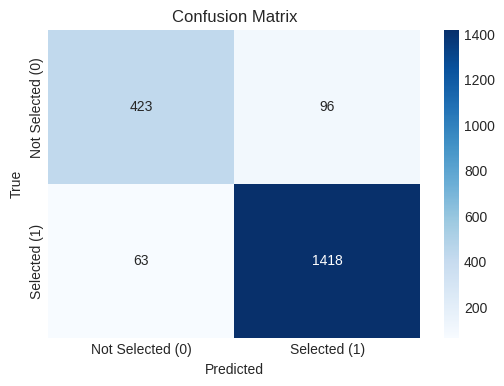


Classification Report:
               precision    recall  f1-score   support

Not Selected       0.87      0.82      0.84       519
    Selected       0.94      0.96      0.95      1481

    accuracy                           0.92      2000
   macro avg       0.90      0.89      0.89      2000
weighted avg       0.92      0.92      0.92      2000

Decision tree training completed:
Training accuracy: 0.929
Test accuracy: 0.920
Top 5 most important features:
  performance_score: 0.531
  lifetime_prediction: 0.230
  gradient_quality: 0.094
  data_quality: 0.080
  battery_level: 0.027


True

In [32]:
class DecisionTreeSelector:
    """Decision tree-based device selection"""

    def __init__(self):
        self.model = DecisionTreeClassifier(
            max_depth=6,  # Increased for more complex features
            # min_samples_split=25,
            # min_samples_leaf=15,
            random_state=42,
            # class_weight="balanced",  # Handle class imbalance
            criterion="entropy",
        )
        self.scaler = StandardScaler()
        self.is_trained = False
        self.feature_names = [
            "battery_level",
            "memory_ratio",
            "network_reliability",
            "data_quality",
            "rounds_since_participation",
            "reliability_score",
            "data_volume",
            "gradient_quality",
            "performance_score",
            "lifetime_prediction",
            "network_stability",
            "battery_health",
            "memory_efficiency",
            "performance_trend",
            "failure_probability",
            "temperature_impact",
            "workload_intensity",
        ]
        self.feature_importance = None
        self.training_history = []

    def train(self, training_data_path="device_selection_training_data.csv"):
        """Train the decision tree model"""
        try:
            df = pd.read_csv(training_data_path)
            encoder = LabelEncoder()
            df["device_type"] = encoder.fit_transform(df["device_type"])
            X = df[self.feature_names].values
            y = df["should_select"].values

            # Handle any missing values
            X = np.nan_to_num(X, nan=0.0)
            y = np.nan_to_num(y, nan=0)

            # Split data
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=y
            )

            # Scale features
            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)

            # Train model
            self.model.fit(X_train_scaled, y_train)

            # Store feature importance
            self.feature_importance = dict(
                zip(self.feature_names, self.model.feature_importances_)
            )

            # Evaluate
            train_accuracy = self.model.score(X_train_scaled, y_train)
            test_accuracy = self.model.score(X_test_scaled, y_test)

            # Visualize the decision tree with graphviz
            tree.plot_tree(self.model.fit(X_train_scaled, y_train))

            # Display the confusion matrix
            y_pred = self.model.predict(X_test_scaled)
            cm = confusion_matrix(y_test, y_pred)
            
            plt.figure(figsize=(6, 4))
            sns.heatmap(
                cm,
                annot=True,
                fmt="d",
                cmap="Blues",
                xticklabels=["Not Selected (0)", "Selected (1)"],
                yticklabels=["Not Selected (0)", "Selected (1)"],
            )
            plt.xlabel("Predicted")
            plt.ylabel("True")
            plt.title("Confusion Matrix")
            plt.show()

            print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Not Selected", "Selected"]))

            # Store training history
            training_record = {
                "timestamp": time.time(),
                "train_samples": len(X_train),
                "test_samples": len(X_test),
                "train_accuracy": train_accuracy,
                "test_accuracy": test_accuracy,
                "feature_count": len(self.feature_names),
            }
            self.training_history.append(training_record)

            print(f"Decision tree training completed:")
            print(f"Training accuracy: {train_accuracy:.3f}")
            print(f"Test accuracy: {test_accuracy:.3f}")
            print(f"Top 5 most important features:")

            sorted_importance = sorted(
                self.feature_importance.items(), key=lambda x: x[1], reverse=True
            )
            for feature, importance in sorted_importance[:5]:
                print(f"  {feature}: {importance:.3f}")

            self.is_trained = True
            return True

        except FileNotFoundError:
            print(
                "Training data file not found. Generate data first using generate_decision_tree_training_data()"
            )
            return False
        except Exception as e:
            print(e.with_traceback)
            print(f"Error during training: {e}")
            return False

    def predict_selection_probability(self, device: IoTDevice) -> float:
        """Predict selection probability for a device"""
        if not self.is_trained:
            return 0.5  # Default probability if model not trained

        try:
            features = device.get_selection_features().reshape(1, -1)

            # Handle feature dimension mismatch
            if features.shape[1] != len(self.feature_names):
                print(
                    f"Warning: Feature dimension mismatch. Expected {len(self.feature_names)}, got {features.shape[1]}"
                )
                # Pad with zeros if needed
                if features.shape[1] < len(self.feature_names):
                    padding = np.zeros((1, len(self.feature_names) - features.shape[1]))
                    features = np.concatenate([features, padding], axis=1)
                else:
                    features = features[:, : len(self.feature_names)]

            features_scaled = self.scaler.transform(features)
            probabilities = self.model.predict_proba(features_scaled)
            return probabilities[0][1] if probabilities.shape[1] > 1 else 0.5

        except Exception as e:
            print(f"Error in prediction for device {device.device_id}: {e}")
            return 0.5

    def retrain_with_new_data(self, recent_performance_data: List[Dict]):
        """Retrain model with recent performance data"""
        if not recent_performance_data:
            return False

        # This would implement online learning or incremental updates
        # For now, we'll simulate by adjusting feature weights based on recent performance
        print(f"Retraining with {len(recent_performance_data)} recent samples")
        return True


# Initialize and train the decision tree selector
dt_selector = DecisionTreeSelector()
dt_selector.train()

#### 5.3. Temporal State Evolution and Monitoring

In [11]:
class NetworkHealthMonitor:
    """System-wide network health monitoring"""
    
    def __init__(self):
        self.device_health_history = defaultdict(list)
        self.network_events = []
        self.alert_thresholds = {
            'battery_critical': 10,
            'failure_probability_high': 0.8,
            'network_degraded': 0.3,
            'memory_pressure_high': 0.8
        }
    
    def collect_device_telemetry(self, devices: List[IoTDevice]):
        """Collect telemetry from all devices"""
        current_time = time.time()
        
        for device in devices:
            health_data = {
                'timestamp': current_time,
                'device_id': device.device_id,
                'battery_level': device.battery.current_level,
                'battery_health': device.battery.health_percentage,
                'network_stability': device.bandwidth.connection_stability,
                'memory_pressure': device.memory.memory_pressure,
                'failure_probability': device.health_metrics.failure_probability,
                'performance_score': device._calculate_performance_score(),
                'predicted_lifetime': device.predict_remaining_lifetime()
            }
            
            self.device_health_history[device.device_id].append(health_data)
            
            # Keep only last 1000 records per device
            if len(self.device_health_history[device.device_id]) > 1000:
                self.device_health_history[device.device_id] = \
                    self.device_health_history[device.device_id][-1000:]
            
            # Check for alerts
            self._check_device_alerts(health_data)
    
    def _check_device_alerts(self, health_data: Dict):
        """Check for alert conditions"""
        alerts = []
        
        if health_data['battery_level'] < self.alert_thresholds['battery_critical']:
            alerts.append(f"CRITICAL: Device {health_data['device_id']} battery at {health_data['battery_level']:.1f}%")
        
        if health_data['failure_probability'] > self.alert_thresholds['failure_probability_high']:
            alerts.append(f"WARNING: Device {health_data['device_id']} high failure risk: {health_data['failure_probability']:.2f}")
        
        if health_data['network_stability'] < self.alert_thresholds['network_degraded']:
            alerts.append(f"NETWORK: Device {health_data['device_id']} poor connectivity: {health_data['network_stability']:.2f}")
        
        for alert in alerts:
            self.network_events.append({
                'timestamp': health_data['timestamp'],
                'type': 'ALERT',
                'message': alert
            })
    
    def get_network_health_summary(self, devices: List[IoTDevice]) -> Dict:
        """Get overall network health summary"""
        if not devices:
            return {}
        
        # Collect current metrics
        battery_levels = [d.battery.current_level for d in devices]
        performance_scores = [d._calculate_performance_score() for d in devices]
        failure_probs = [d.health_metrics.failure_probability for d in devices]
        network_stabilities = [d.bandwidth.connection_stability for d in devices]
        
        summary = {
            'total_devices': len(devices),
            'active_devices': len([d for d in devices if d.is_active]),
            'avg_battery_level': np.mean(battery_levels),
            'min_battery_level': np.min(battery_levels),
            'avg_performance_score': np.mean(performance_scores),
            'high_risk_devices': len([p for p in failure_probs if p > 0.7]),
            'network_stability': np.mean(network_stabilities),
            'devices_needing_attention': len([d for d in devices if 
                d.battery.current_level < 20 or 
                d.health_metrics.failure_probability > 0.6 or
                d.bandwidth.connection_stability < 0.4])
        }
        
        return summary

class DeviceFailureSimulator:
    """Simulate realistic device failures and recovery"""
    
    @staticmethod
    def simulate_random_failures(devices: List[IoTDevice], failure_rate: float = 0.001):
        """Simulate random device failures"""
        failed_devices = []
        
        for device in devices:
            # Failure probability increases with device health issues
            base_failure_prob = failure_rate
            health_multiplier = 1 + device.health_metrics.failure_probability * 10
            effective_failure_prob = min(0.1, base_failure_prob * health_multiplier)
            
            if random.random() < effective_failure_prob:
                device.is_active = False
                device.battery.current_level = 0
                failed_devices.append(device.device_id)
                logger.warning(f"Device {device.device_id} failed due to hardware issues")
        
        return failed_devices
    
    @staticmethod
    def simulate_recovery(devices: List[IoTDevice], recovery_rate: float = 0.01):
        """Simulate device recovery (repair/replacement)"""
        recovered_devices = []
        
        for device in devices:
            if not device.is_active and random.random() < recovery_rate:
                # Reset device to operational state
                device.is_active = True
                device.battery.current_level = random.uniform(70, 100)
                device.battery.health_percentage = random.uniform(80, 100)
                device.health_metrics.failure_probability = 0.0
                recovered_devices.append(device.device_id)
                logger.info(f"Device {device.device_id} recovered and back online")
        
        return recovered_devices


#### 5.4. Client Selection Policies

In [12]:
class ClientSelectionPolicy:
    """Client/Device selection policy framework"""

    @staticmethod
    def random_selection(
        devices: List[IoTDevice], selection_size: int
    ) -> List[IoTDevice]:
        """Random device selection"""
        eligible_devices = [d for d in devices if d.can_participate()]
        if len(eligible_devices) < selection_size:
            return eligible_devices
        return random.sample(eligible_devices, selection_size)
    
    @staticmethod
    def decision_tree_selection(
        devices: List[IoTDevice], 
        selection_size: int,
        dt_selector: DecisionTreeSelector
    ) -> List[IoTDevice]:
        """Decision tree-based device selection"""
        eligible_devices = [d for d in devices if d.can_participate()]
        
        if not eligible_devices:
            return []
        
        # Get selection probabilities for all eligible devices
        device_scores = []
        for device in eligible_devices:
            probability = dt_selector.predict_selection_probability(device)
            device_scores.append((device, probability))
        
        # Sort by probability and select top devices
        device_scores.sort(key=lambda x: x[1], reverse=True)
        selected = [device for device, _ in device_scores[:selection_size]]
        
        print(f"Decision tree selected {len(selected)} devices with avg probability: "
              f"{np.mean([score for _, score in device_scores[:selection_size]]):.3f}")
        
        return selected

    @staticmethod
    def resource_aware_selection(
        devices: List[IoTDevice], selection_size: int
    ) -> List[IoTDevice]:
        """Resource-aware device selection (future implementation)"""
        eligible_devices = [d for d in devices if d.can_participate()]

        # Score devices based on resources
        scored_devices = []
        for device in eligible_devices:
            score = (
                device.battery_state.current_level * 0.4
                + (device.memory_state.free_ram / device.memory_state.total_ram)
                * 100
                * 0.3
                + (100 - device.bandwidth_state.packet_loss) * 0.3
            )
            scored_devices.append((device, score))

        # Select top devices
        scored_devices.sort(key=lambda x: x[1], reverse=True)
        return [d[0] for d in scored_devices[:selection_size]]

#### 5.5. Autonomic Manager (Gateway)

In [13]:
class Gateway:
    def __init__(
        self,
        gateway_id: str = "gateway_001",
        location: Tuple[float, float] = (0.0, 0.0),
    ):
        self.gateway_id = gateway_id
        self.location = location
        self.connected_devices: Dict[str, IoTDevice] = {}
        self.selected_devices: List[IoTDevice] = []
        self.received_packets: List[Packet] = []
        self.monitoring_data: Dict[str, List[Dict]] = {}
        self.is_running = False
        self.creation_time = time.time()
        self.health_monitor = NetworkHealthMonitor()
        self.last_health_check = time.time()
        self.device_failure_simulator = DeviceFailureSimulator()

        # Gateway capabilities
        self.total_bandwidth = 100.0  # Mbps
        self.current_bandwidth_usage = 0.0
        self.max_devices = 1000
        self.packet_processing_delay = 0.001  # seconds per packet

        # Gateway statistics
        self.stats = {
            "total_packets_processed": 0,
            "packets_dropped": 0,
            "average_latency": 0.0,
            "peak_bandwidth_usage": 0.0,
            "device_failures": 0,
        }
        self.packet_history = []
        self.round_statistics = []

        logger.info(f"Gateway {gateway_id} initialized at {location}")

    def register_device(self, device: IoTDevice):
        """Register an IoT device with the gateway"""
        if len(self.connected_devices) >= self.max_devices:
            logger.error(
                f"Gateway capacity exceeded. Cannot register device {device.device_id}"
            )
            return False

        self.connected_devices[device.device_id] = device
        self.monitoring_data[device.device_id] = []
        logger.info(
            f"Device {device.device_id} registered with gateway at {device.location}"
        )
        return True

    def monitor_network_health(self):
        """Monitor overall network health"""
        devices = list(self.connected_devices.values())
        self.health_monitor.collect_device_telemetry(devices)

        # Simulate device failures and recoveries
        failed = self.device_failure_simulator.simulate_random_failures(devices)
        recovered = self.device_failure_simulator.simulate_recovery(devices)

        if failed:
            logger.warning(f"Devices failed this round: {failed}")
        if recovered:
            logger.info(f"Devices recovered this round: {recovered}")

        return self.health_monitor.get_network_health_summary(devices)

    def update_all_device_states(self, time_delta: float):
        """Update temporal states for all connected devices"""
        for device in self.connected_devices.values():
            device.simulate_time_passage(time_delta)

    def _train_selection_model(self):
        """Train a decision tree model to predict device reliability"""
        pass

    def receive_packet(self, packet: Packet):
        """Process received packet and extract monitoring data"""
        processing_start = time.time()

        # Check if gateway is overloaded
        current_load = len(self.received_packets) * self.packet_processing_delay
        if current_load > 1.0:  # More than 1 second of processing backlog
            self.stats["packets_dropped"] += 1
            logger.warning(
                f"Packet dropped due to gateway overload from {packet.source_id}"
            )
            return False

        self.received_packets.append(packet)
        self.stats["total_packets_processed"] += 1

        # Store monitoring data
        if packet.data and packet.source_id in self.monitoring_data:
            data = {
                "timestamp": packet.timestamp,
                "packet_size": packet.size,
                "packet_type": packet.packet_type,
                # "priority": packet.priority,
                "retry_count": packet.retry_count,
                "processing_delay": time.time() - processing_start,
                **packet.data,
            }
            self.monitoring_data[packet.source_id].append(data)

            # Keep only last 1000 records per device to manage memory
            if len(self.monitoring_data[packet.source_id]) > 1000:
                self.monitoring_data[packet.source_id] = self.monitoring_data[
                    packet.source_id
                ][-1000:]

        # Update gateway statistics
        processing_time = time.time() - processing_start
        self.stats["average_latency"] = (
            self.stats["average_latency"] * 0.9 + processing_time * 0.1
        )

        return True

    def select_devices(
        self,
        devices: List[IoTDevice],
        selection_size: int,
        policy: str = "random",
        dt_selector: DecisionTreeSelector = None,
    ) -> None:
        """Select devices for training round"""
        if policy == "random":
            self.selected_devices = ClientSelectionPolicy.random_selection(
                devices, selection_size
            )
        elif policy == "resource_aware":
            self.selected_devices = ClientSelectionPolicy.resource_aware_selection(
                devices, selection_size
            )
        elif policy == "decision_tree":
            if dt_selector and dt_selector.is_trained:
                self.selected_devices = ClientSelectionPolicy.decision_tree_selection(
                    devices, selection_size, dt_selector
                )
            else:
                print("Decision tree not trained, falling back to random selection")
                self.selected_devices = ClientSelectionPolicy.random_selection(
                    devices, selection_size
                )
        else:
            raise ValueError(f"Unknown policy: {policy}")

    def broadcast_global_model(
        self,
        round_num: int,
        global_model: dict[str, any],
    ):
        """Simulate broadcasting global model to selected devices"""

        for device in self.selected_devices:
            packet = device.train_model_and_generate_packet(
                destination=self.gateway_id,
                epochs=1,
                global_update=global_model,
                round_num=round_num,
            )
            if packet:
                success, packet = device.transmit_packet()
                if success and packet and packet.data:
                    self.receive_packet(packet)

        # This is a simplified simulation - just record the action
        print(
            f"Round {round_num}: Broadcasting global model to {len(self.selected_devices)} devices"
        )

### 6. Cloud Server building

#### 6.1. Model Aggregation Methods

In [14]:
class AggregationMethods:
    """Federated learning aggregation methods"""

    def fed_avg(weights_list: List[Dict]) -> Dict:
        avg_weights = copy.deepcopy(weights_list[0])
        for key in avg_weights:
            for i in range(1, len(weights_list)):
                avg_weights[key] += weights_list[i][key]
            avg_weights[key] = avg_weights[key] / len(weights_list)
        return avg_weights

    def fed_median(self, weights_list):
        median_weights = copy.deepcopy(weights_list[0])
        for key in median_weights:
            all_weights = torch.stack([weights[key] for weights in weights_list], dim=0)
            median_weights[key] = torch.median(all_weights, dim=0).values
        return median_weights
    def fed_round_robin(self, weights_list, round_num):
        index = round_num % len(weights_list)
        return weights_list[index]
    def fed_weighted_avg(self, weights_list, weights):
        avg_weights = copy.deepcopy(weights_list[0])
        total_weight = sum(weights)
        for key in avg_weights:
            avg_weights[key] = sum(weights[i] * weights_list[i][key] for i in range(len(weights_list))) / total_weight
        return avg_weights
    def fed_krum(self, weights_list, f=1):
        num_clients = len(weights_list)
        scores = []
        for i in range(num_clients):
            distances = []
            for j in range(num_clients):
                if i != j:
                    dist = sum(torch.sum((weights_list[i][key] - weights_list[j][key])**2).item() for key in weights_list[i])
                    distances.append(dist)
            distances.sort()
            score = sum(distances[:num_clients - f - 2])
            scores.append(score)
        krum_index = scores.index(min(scores))
        return weights_list[krum_index]
    def fed_bulyan(self, weights_list, f=1):
        num_clients = len(weights_list)
        selected = []
        temp_weights = weights_list.copy()
        for _ in range(num_clients - 2 * f):
            scores = []
            for i in range(len(temp_weights)):
                distances = []
                for j in range(len(temp_weights)):
                    if i != j:
                        dist = sum(torch.sum((temp_weights[i][key] - temp_weights[j][key])**2).item() for key in temp_weights[i])
                        distances.append(dist)
                distances.sort()
                score = sum(distances[:num_clients - f - 2])
                scores.append(score)
            min_index = scores.index(min(scores))
            selected.append(temp_weights[min_index])
            temp_weights.pop(min_index)
        return self.fed_avg(selected)


#### 6.2. Central/Cloud Server

In [15]:
class CloudServer:
    def __init__(
        self, server_id: str = "cloud_server", global_model: SimpleNet = SimpleNet()
    ):
        self.server_id = server_id
        self.connected_gateways: Dict[str, Gateway] = {}
        self.global_model = global_model
        self.global_model_state = None
        self.creation_time = time.time()

        # Server capabilities
        self.model_update_interval = 3600  # 1 hour
        self.last_model_update = time.time()
        self.stats = {
            "total_gateways": 0,
            "total_devices": 0,
            "model_updates": 0,
            "aggregation_time": 0.0,
        }
        logger.info(f"Cloud server {server_id} initialized")

    def register_gateway(self, gateway: Gateway):
        """Register a gateway with the cloud server"""
        if gateway.gateway_id in self.connected_gateways:
            logger.warning(f"Gateway {gateway.gateway_id} already registered")
            return False

        self.connected_gateways[gateway.gateway_id] = gateway
        self.stats["total_gateways"] += len(gateway.connected_devices)
        logger.info(f"Gateway {gateway.gateway_id} registered with cloud server")
        return True

    def aggregate_model_updates(self, packets: List[Dict] = []):
        """Aggregate model updates from all connected clients/devices"""
        if not packets:
            logger.warning("No packets received for aggregation")
            return
        self.global_model_state = AggregationMethods.fed_avg(weights_list=packets)
        self.global_model.load_state_dict(self.global_model_state)
        self.last_model_update = time.time()
        logger.info(f"Global model updated with {len(packets)} local models")

    def collect_system_telemetry(self) -> Dict:
        """Collect system-wide telemetry for decision tree retraining"""
        telemetry = {
            "timestamp": time.time(),
            "total_devices": sum(
                len(gw.connected_devices) for gw in self.connected_gateways.values()
            ),
            "gateway_health": {},
        }

        for gw_id, gateway in self.connected_gateways.items():
            health_summary = gateway.monitor_network_health()
            telemetry["gateway_health"][gw_id] = health_summary

        return telemetry

    def distribute_global_model(self):
        """Distribute the global model to all connected gateways and their devices"""
        # for gateway in self.connected_gateways.values():
        #     for device in gateway.connected_devices.values():
        #         device.local_model.load_state_dict(self.global_model.state_dict())
        # logger.info("Global model distributed to all connected devices")
        return

### 7. Simulator building

#### 7.1. Enhanced Monitoring Dashboard

In [16]:
def create_device_health_dashboard(devices: List[IoTDevice], save_plot: bool = True):
    """Create visual dashboard of device health metrics"""
    if not devices:
        return
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('IoT Device Health Dashboard', fontsize=16)
    
    # Battery levels
    battery_levels = [d.battery.current_level for d in devices if d.is_active]
    axes[0, 0].hist(battery_levels, bins=20, alpha=0.7, color='green')
    axes[0, 0].set_title('Battery Level Distribution')
    axes[0, 0].set_xlabel('Battery Level (%)')
    axes[0, 0].axvline(x=20, color='red', linestyle='--', label='Critical')
    axes[0, 0].legend()
    
    # Performance scores
    perf_scores = [d._calculate_performance_score() for d in devices if d.is_active]
    axes[0, 1].hist(perf_scores, bins=20, alpha=0.7, color='blue')
    axes[0, 1].set_title('Performance Score Distribution')
    axes[0, 1].set_xlabel('Performance Score')
    
    # Failure probabilities
    failure_probs = [d.health_metrics.failure_probability for d in devices if d.is_active]
    axes[0, 2].hist(failure_probs, bins=20, alpha=0.7, color='red')
    axes[0, 2].set_title('Failure Probability Distribution')
    axes[0, 2].set_xlabel('Failure Probability')
    
    # Network stability
    network_stability = [d.bandwidth.connection_stability for d in devices if d.is_active]
    axes[1, 0].hist(network_stability, bins=20, alpha=0.7, color='purple')
    axes[1, 0].set_title('Network Stability Distribution')
    axes[1, 0].set_xlabel('Connection Stability')
    
    # Device locations colored by health
    x_coords = [d.location[0] for d in devices if d.is_active]
    y_coords = [d.location[1] for d in devices if d.is_active]
    colors = [d._calculate_performance_score() for d in devices if d.is_active]
    
    scatter = axes[1, 1].scatter(x_coords, y_coords, c=colors, cmap='RdYlGn', alpha=0.7)
    axes[1, 1].set_title('Device Health by Location')
    axes[1, 1].set_xlabel('X Coordinate')
    axes[1, 1].set_ylabel('Y Coordinate')
    plt.colorbar(scatter, ax=axes[1, 1], label='Performance Score')
    
    # Device type health comparison
    device_types = {}
    for device in devices:
        if device.is_active:
            if device.device_type not in device_types:
                device_types[device.device_type] = []
            device_types[device.device_type].append(device._calculate_performance_score())
    
    if device_types:
        type_names = list(device_types.keys())
        type_scores = [np.mean(scores) for scores in device_types.values()]
        axes[1, 2].bar(type_names, type_scores, alpha=0.7)
        axes[1, 2].set_title('Average Performance by Device Type')
        axes[1, 2].set_ylabel('Performance Score')
        axes[1, 2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    if save_plot:
        plt.savefig('device_health_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_system_health_report(health_summary: Dict):
    """Print formatted system health report"""
    print("\n" + "="*60)
    print("SYSTEM HEALTH REPORT")
    print("="*60)
    print(f"Total Devices: {health_summary.get('total_devices', 0)}")
    print(f"Active Devices: {health_summary.get('active_devices', 0)}")
    print(f"Average Battery Level: {health_summary.get('avg_battery_level', 0):.1f}%")
    print(f"Minimum Battery Level: {health_summary.get('min_battery_level', 0):.1f}%")
    print(f"Average Performance Score: {health_summary.get('avg_performance_score', 0):.3f}")
    print(f"High Risk Devices: {health_summary.get('high_risk_devices', 0)}")
    print(f"Network Stability: {health_summary.get('network_stability', 0):.3f}")
    print(f"Devices Needing Attention: {health_summary.get('devices_needing_attention', 0)}")
    
    # Health status classification
    if health_summary.get('avg_battery_level', 0) > 50:
        battery_status = "GOOD"
    elif health_summary.get('avg_battery_level', 0) > 20:
        battery_status = "WARNING"
    else:
        battery_status = "CRITICAL"
    
    network_stability = health_summary.get('network_stability', 0)
    if network_stability > 0.7:
        network_status = "EXCELLENT"
    elif network_stability > 0.5:
        network_status = "GOOD"
    elif network_stability > 0.3:
        network_status = "DEGRADED"
    else:
        network_status = "POOR"
    
    print(f"\nOVERALL STATUS:")
    print(f"Battery Health: {battery_status}")
    print(f"Network Health: {network_status}")
    print("="*60)


#### 7.2. Simulator

In [ ]:
class FederatedLearningSystem:
    def __init__(
        self,
        selection_size: int = 6,
        simulation_area: Tuple[int, int] = (1000, 1000),
        data_heterogeneity: float = 0.5,
    ):
        self.num_devices: int = 0
        self.selection_size = selection_size
        self.gateway = Gateway()
        self.cloud_server = CloudServer()
        self.devices = List[IoTDevice]
        self.system_start_time = None
        self.system_end_time = None
        self.simulation_area = simulation_area  # (width, height) in meters
        self.real_time_data: Dict[str, Dict] = {}
        self.data_heterogeneity = data_heterogeneity
        self.client_datasets = {}
        self.client_stats = {}
        self.dt_selector = DecisionTreeSelector()

        # Register gateway with Cloud Server
        self.cloud_server.register_gateway(self.gateway)

    # Create devices with configurations
    def add_device(
        self,
        device_id: str,
        device_type: str = "sensor",
        initial_battery: float = 100.0,
        location: Optional[Tuple[float, float]] = None,
    ):
        """Add IoT device with enhanced positioning and configuration"""
        if location is None:
            # Random placement within simulation area
            location = (
                random.uniform(0, self.simulation_area[0]),
                random.uniform(0, self.simulation_area[1]),
            )

        device = IoTDevice(
            device_id,
            device_type,
            initial_battery,
            location,
            local_model=SimpleNet(),
        )

        if self.gateway.register_device(device):
            self.num_devices += 1
            self.real_time_data[device_id] = {
                "timestamps": [],
                "battery": [],
                "memory": [],
                "bandwidth": [],
                "packet_loss": [],
                "latency": [],
                "temperature": [],
            }
            logger.info(f"Device {device_id} ({device_type}) added at {location}")
            return True
        return False

    def add_device_cluster(
        self,
        cluster_center: Tuple[float, float],
        cluster_radius: float,
        device_count: int,
        device_type: str = "sensor",
    ):
        """Add a cluster of devices around a central point"""
        for i in range(device_count):
            # Random position within cluster radius
            angle = random.uniform(0, 2 * np.pi)
            radius = random.uniform(0, cluster_radius)

            x = cluster_center[0] + radius * np.cos(angle)
            y = cluster_center[1] + radius * np.sin(angle)

            # Ensure device stays within simulation area
            x = max(0, min(x, self.simulation_area[0]))
            y = max(0, min(y, self.simulation_area[1]))

            device_id = f"{device_type}_cluster_{i:01d}"
            self.add_device(
                device_id,
                device_type,
                initial_battery=random.uniform(70, 100),
                location=(x, y),
            )

    def setup_federated_data_distribution(self):
        """Setup non-IID data distribution among clients"""
        print("Setting up non-IID data distribution...")

        # Create data splits
        self.client_datasets, self.client_stats = create_non_iid_data_split(
            train_dataset,
            len(self.gateway.connected_devices),
            alpha=self.data_heterogeneity,
        )

        # Assign data to devices
        for i, (device_id, device) in enumerate(self.gateway.connected_devices.items()):
            client_key = f"client_{i}"
            if client_key in self.client_datasets:
                device.assign_local_data(
                    train_dataset, self.client_datasets[client_key]
                )

        print(f"Data distribution completed for {len(self.client_datasets)} clients")
        print(
            f"Average samples per client: {np.mean([stats['total_samples'] for stats in self.client_stats.values()]):.1f}"
        )

    def run_simulation(self, num_rounds: int = 10, policy: str = "random") -> Dict:
        """Run the complete federated learning simulation"""
        print(f"Starting Federated Learning Simulation")
        
        # Setup federated data distribution
        self.setup_federated_data_distribution()

        print(
            f"Devices: {self.num_devices}, Selection: {self.selection_size}, Rounds: {num_rounds}"
        )
        print(f"Policy: {policy}")
        print("=" * 60)

        self.system_start_time = time.time()

        for round_num in range(num_rounds):
            print(f"\n--- Round {round_num + 1}/{num_rounds} ---")

            # Update device states based on time passage
            time_since_last_round = 300  # Assume 5 minutes between rounds
            self.gateway.update_all_device_states(time_since_last_round)
            
            # Monitor network health
            health_summary = self.gateway.monitor_network_health()
            
            # Print health summary every few rounds
            if (round_num + 1) % 3 == 0:
                print_system_health_report(health_summary)

            # Select devices for this round
            if policy == "decision_tree":
                self.gateway.select_devices(
                    list(self.gateway.connected_devices.values()), 
                    self.selection_size, 
                    policy,
                    dt_selector=dt_selector
                )
            else:
                self.gateway.select_devices(
                    list(self.gateway.connected_devices.values()), 
                    self.selection_size, 
                    policy
                )

            active_devices = len(
                [d for d in self.gateway.connected_devices.values() if d.is_active]
            )
            print(f"Active devices: {active_devices}/{self.num_devices}")
            print(f"Selected for training: {len(self.gateway.selected_devices)}")

            # Broadcast global model and Local Models train
            self.gateway.broadcast_global_model(
                round_num,
                self.cloud_server.global_model.state_dict(),
            )
            time.sleep(1)  # Simulate time delay for training

            # Aggregate updates at cloud server
            packets = [
                self.gateway.monitoring_data[dev.device_id][-1]["local_update"]
                for dev in self.gateway.selected_devices
                if self.gateway.monitoring_data[dev.device_id]
                and "local_update" in self.gateway.monitoring_data[dev.device_id][-1]
            ]

            print(f"Received {len(packets)} model updates for aggregation")
            self.cloud_server.aggregate_model_updates(packets=packets)
            self.cloud_server.distribute_global_model()

            time.sleep(1)  # Simulate time delay for distribution

            # Evaluate the global model for the current round
            eval_accuracy = evaluate(
                model=self.cloud_server.global_model, loader=test_loader
            )
            print(
                f"✅ Global model evaluation accuracy | round {round_num}: {eval_accuracy*100:.2f}%"
            )

            # Generate round statistics

        # Evaluate the global model at the end
        eval_accuracy = evaluate(
            model=self.cloud_server.global_model, loader=test_loader
        )
        print(f"\n🏁 Final Global model evaluation accuracy: {eval_accuracy*100:.2f}%")

        # Generate final health dashboard
        devices_list = list(self.gateway.connected_devices.values())
        create_device_health_dashboard(devices_list, save_plot=True)
        
        # Final system telemetry
        final_telemetry = self.cloud_server.collect_system_telemetry()
        print(f"\n🔍 Final System Telemetry:")
        print(f"Total devices monitored: {final_telemetry['total_devices']}")
        for gw_id, health in final_telemetry['gateway_health'].items():
            print(f"Gateway {gw_id} - Active: {health.get('active_devices', 0)}/{health.get('total_devices', 0)}")

        self.system_end_time = time.time()

        # Generate final system report

    def _generate_system_statistics(self) -> Dict:
        """Generate comprehensive system statistics"""
        total_time = self.system_end_time - self.system_start_time
        final_active = len(
            [d for d in self.gateway.connected_devices.values() if d.is_active]
        )

        # Calculate round statistics
        round_durations = [r["round_duration"] for r in self.gateway.round_statistics]
        successful_rates = [
            r["successful_updates"] / r["selected_devices"]
            for r in self.gateway.round_statistics
            if r["selected_devices"] > 0
        ]

        return {
            "total_execution_time": total_time,
            "final_active_devices": final_active,
            "avg_round_duration": np.mean(round_durations),
            "min_round_duration": np.min(round_durations),
            "max_round_duration": np.max(round_durations),
            "avg_success_rate": np.mean(successful_rates),
            "total_packets_sent": len(self.gateway.packet_history),
            "round_statistics": self.gateway.round_statistics,
        }

### 8. Run Simulation

Starting Federated Learning Simulation
Setting up non-IID data distribution...
Data distribution completed for 27 clients
Average samples per client: 2082.9
Devices: 27, Selection: 6, Rounds: 5
Policy: random

--- Round 1/5 ---
Active devices: 27/27
Selected for training: 6


Round 0: Broadcasting global model to 6 devices
Received 6 model updates for aggregation
Test accuracy: 0.9726999998092651
✅ Global model accuracy: 0.9727
✅ Global model evaluation accuracy | round 0: 97.27%

--- Round 2/5 ---
Active devices: 27/27
Selected for training: 6


Round 1: Broadcasting global model to 6 devices
Received 6 model updates for aggregation
Test accuracy: 0.9872000217437744
✅ Global model accuracy: 0.9872
✅ Global model evaluation accuracy | round 1: 98.72%

--- Round 3/5 ---

SYSTEM HEALTH REPORT
Total Devices: 27
Active Devices: 27
Average Battery Level: 78.6%
Minimum Battery Level: 34.5%
Average Performance Score: 0.920
High Risk Devices: 0
Network Stability: 0.929
Devices Needing Attention: 0

OVERALL STATUS:
Battery Health: GOOD
Network Health: EXCELLENT
Active devices: 27/27
Selected for training: 6


Round 2: Broadcasting global model to 6 devices
Received 6 model updates for aggregation
Test accuracy: 0.9882000088691711
✅ Global model accuracy: 0.9882
✅ Global model evaluation accuracy | round 2: 98.82%

--- Round 4/5 ---
Active devices: 27/27
Selected for training: 6


Round 3: Broadcasting global model to 6 devices
Received 6 model updates for aggregation
Test accuracy: 0.9891999959945679
✅ Global model accuracy: 0.9892
✅ Global model evaluation accuracy | round 3: 98.92%

--- Round 5/5 ---
Active devices: 27/27
Selected for training: 6


Round 4: Broadcasting global model to 6 devices
Received 6 model updates for aggregation
Test accuracy: 0.9878000020980835
✅ Global model accuracy: 0.9878
✅ Global model evaluation accuracy | round 4: 98.78%
Test accuracy: 0.9878000020980835
✅ Global model accuracy: 0.9878

🏁 Final Global model evaluation accuracy: 98.78%


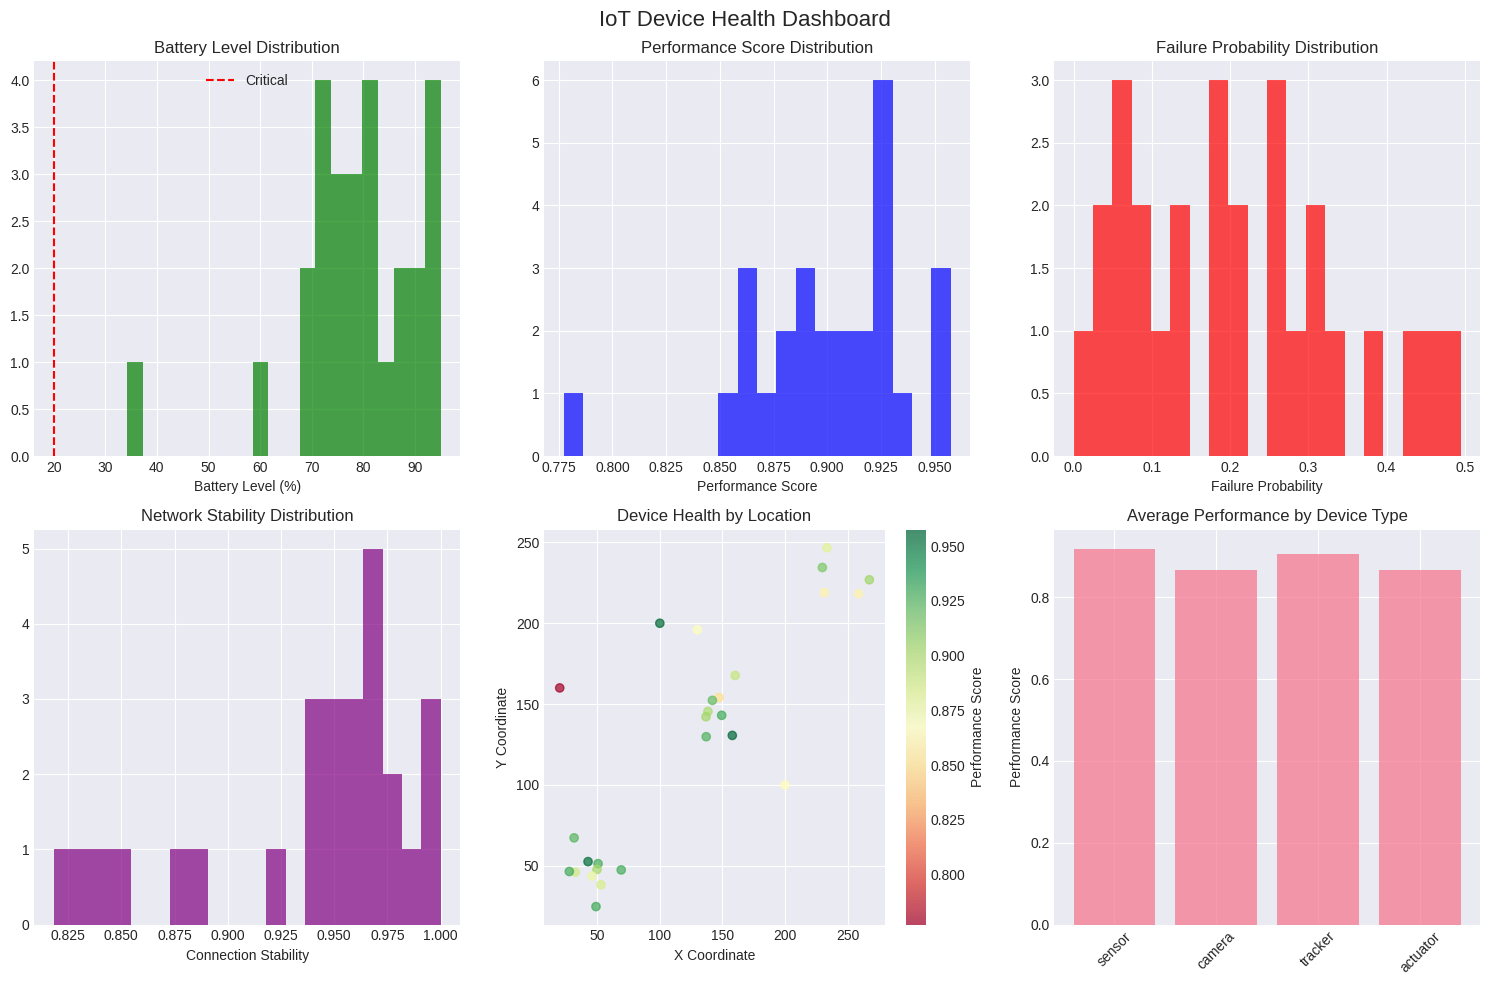


🔍 Final System Telemetry:
Total devices monitored: 27
Gateway gateway_001 - Active: 27/27


In [18]:
sim_env = FederatedLearningSystem(selection_size=6, simulation_area=(300, 300))

# Add various device clusters
sim_env.add_device_cluster(cluster_center=(50, 50), cluster_radius=30, device_count=10, device_type="sensor")
sim_env.add_device_cluster(cluster_center=(250, 250), cluster_radius=40, device_count=5, device_type="camera")
sim_env.add_device_cluster(cluster_center=(150, 150), cluster_radius=25, device_count=8, device_type="tracker")

# Add individual special devices
sim_env.add_device("temp_sensor", "sensor", initial_battery=95, location=(100, 200))
sim_env.add_device("security_camera", "camera", initial_battery=35, location=(20, 160))
sim_env.add_device("asset_tracker", "tracker", initial_battery=70, location=(130, 196))
sim_env.add_device("door_actuator", "actuator", initial_battery=60, location=(200, 100))

logger.info(f"Created simulation with {len(sim_env.gateway.connected_devices)} devices")

# Run simulation
sim_env.run_simulation(num_rounds=5, policy="random")
